# Important



To Execute a cell. Press Shift+Enter or Ctrl+Enter

In [1]:
#load all the necessary libraries
%matplotlib inline
from matplotlib import pyplot as plt
import numpy as np
import math

# Root Finding

## Consider $x = cos(x)$. Our goal is to solve for x that satisfy that.



Plot something that helps you solve it.

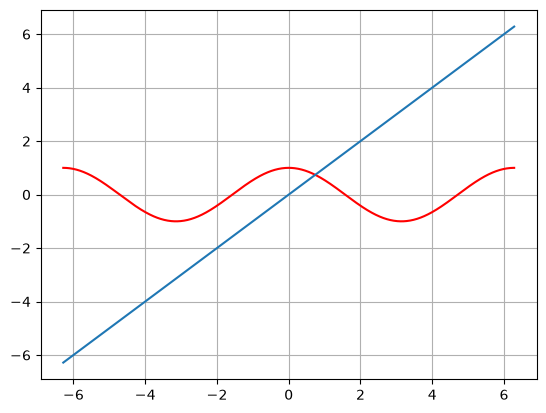

In [2]:
# f(x) = cos(x) 
interval = np.linspace(-2*np.pi, 2*np.pi, 1<<10)
y = np.cos(interval)
plt.grid(True)
plt.plot(interval, y, color='red')
plt.plot(interval, interval)
plt.savefig('05_images/2-1.svg')

## Given the what you did what is your answer?

There exist only a single $x$ value that satisfy $x = \cos(x)$, the value should be in the range of $(0.5, 1)$, precision is low if we just looking at the plot. 

## How accurate is your answer?



$answer = \ldots \pm \ldots$

Accuracy is also an important part for numerical algorithm --> How fast we can improve our accuracy.

Say $0.75 \pm 0.25$? 

Or, if we instead try to find the intersection of the two plot, or the closest pair (with same same index) value.

In [3]:
idx = np.argmin(np.abs(y - interval))
print(interval[idx])

0.7431724556879082


## Make it more accurate

add more interval?

In [4]:
# f(x) = cos(x) 
interval = np.linspace(-2*np.pi, 2*np.pi, 1<<20)
y = np.cos(interval)

idx = np.argmin(np.abs(y - interval))
print(interval[idx])

0.7390858310978725


tighten the bound? (as we already knew there's only one solution, and know roughly where it is, from the plot)

In [5]:
# f(x) = cos(x) 
interval = np.linspace(0.5, 1, 1<<10)
y = np.cos(interval)

idx = np.argmin(np.abs(y - interval))
print(interval[idx])

0.7390029325513197


the two approach got 

## Write the equation above as $f(x)= 0$

$x = cos(x) \rightarrow x - \cos(x) = 0 = f(x)$

# Bisection

## If you use a bisection method and your starting bound is $x=0.2$ and $x=1.2$, how do you know that there is a solution by looking only at $f(0.2)$ and $f(1.2)$

As $f(x) = 0$, the starting bound should contain 0 in their range, so

In [6]:
print(0.2 - np.cos(0.2))

-0.7800665778412417


In [7]:
print(1.2 - np.cos(1.2))

0.8376422455233263


$0 \in (-0.7800665778412417, 0.8376422455233263)$

## Plot the graph along with the two vertical line representing the bound. (use plt.axvline)

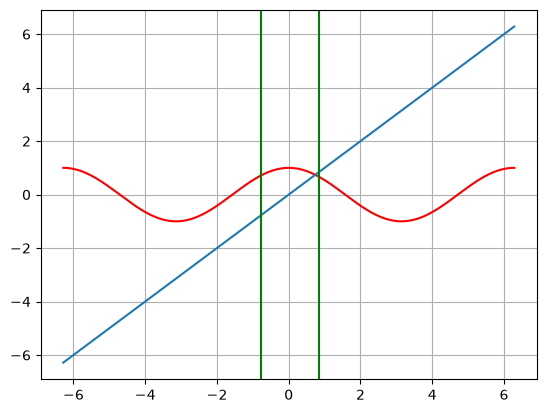

In [8]:
# f(x) = cos(x) 
interval = np.linspace(-2*np.pi, 2*np.pi, 1<<10)
y = np.cos(interval)
plt.grid(True)
plt.plot(interval, y, color='red')
plt.plot(interval, interval)
plt.axvline(0.2 - np.cos(0.2), color='green')
plt.axvline(1.2 - np.cos(1.2), color='green')
plt.savefig('05_images/3-2.svg')

## If we guess right in the middle of the two bound what would be the error on our guess?

$$
    answer = 0.7 \pm 0.5
$$

## If you want to make a new pair of bound which pair would you pick? How did you know?

Do binary search, pick (0.7, 1.2). As

In [9]:
0.7 - np.cos(0.7)

np.float64(-0.06484218728448854)

is lower than 0.0, and we want to pick $f(a) < 0$ and $f(b) > 0$ for $(a, b)$

## Write a function which find solution to f(x)=0 using the method you just discovered. Try plotting as you go.

In [10]:
a = [0.2]
b = [1.2]

x = list(range((1 << 6) + 1))

for _ in range(1 << 6):
    m = (a[-1] + b[-1]) / 2

    fa = a[-1] - np.cos(a[-1])
    fm = m - np.cos(m)

    if (fa > 0 and fm < 0) or (fa < 0 and fm > 0):
        a.append(a[-1])
        b.append(m)
    else:
        a.append(m)
        b.append(b[-1])

In [11]:
print(a[-1] - np.cos(a[-1]))
print(b[-1] - np.cos(b[-1]))
print((a[-1] + b[-1]) / 2)

1.5543122344752192e-15
1.5543122344752192e-15
0.7390851332151616


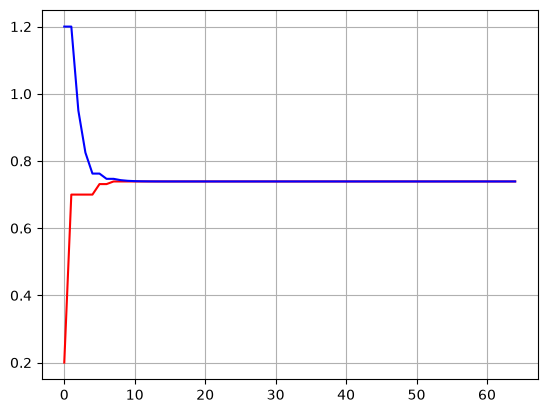

In [12]:
plt.grid(True)
plt.plot(x, a, color='red')
plt.plot(x, b, color='blue')
plt.savefig('05_images/3-5.svg')

## Given that the intial bound is of size $S$. After $n$ iterations how accurate is your answer?

Supposed error in this case means the size of the remaining interval, then

$$\text{error}(n) = S2^{-(n+1)}$$

## Give me the solution to  $x=cos(x)$ that is at most  $10^{−6}$ away from the real answer. Verify your solution graphically.

Using our error(n) estimation, $S = 1.2 - 0.2 = 1.0$, and so

$$10^{-6} = 1.0 \cdot 2^{-(n+1)}$$

then take logarithm on both side

$$
\log_2(10^{-6}) = -(n+1)
$$

Solving for $n$,

$$
n = -1 - \log_2(10^{-6})
$$

In [13]:
-1 - np.log2(1e-6)

np.float64(18.931568569324174)

And so we only need around 19 iteration to get the answer with that tolerance

In [14]:
a = [0.2]
b = [1.2]

x = list(range(21))

for _ in range(20):
    m = (a[-1] + b[-1]) / 2

    fa = a[-1] - np.cos(a[-1])
    fm = m - np.cos(m)

    if (fa > 0 and fm < 0) or (fa < 0 and fm > 0):
        a.append(a[-1])
        b.append(m)
    else:
        a.append(m)
        b.append(b[-1])

In [15]:
print(a[-1] - np.cos(a[-1]))
print(b[-1] - np.cos(b[-1]))
print((a[-1] + b[-1]) / 2)

-1.169362390807116e-06
4.2671826072648855e-07
0.7390849113464355


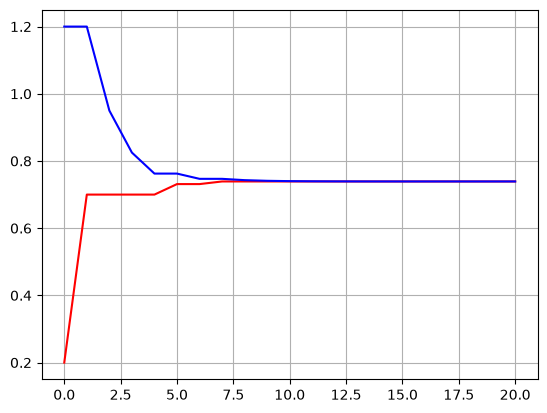

In [16]:
plt.grid(True)
plt.plot(x, a, color='red')
plt.plot(x, b, color='blue')
plt.savefig('05_images/3-6.svg')

# Newton's Method



Let us do someting a bit more efficient. Suppose that we want to solve  $x^3−x=1$  using Newtons's method with initial guess at  $x=2$ . If you start to get lost, PLOT!.

## What is the function that we are trying to find intercept? Plot it.

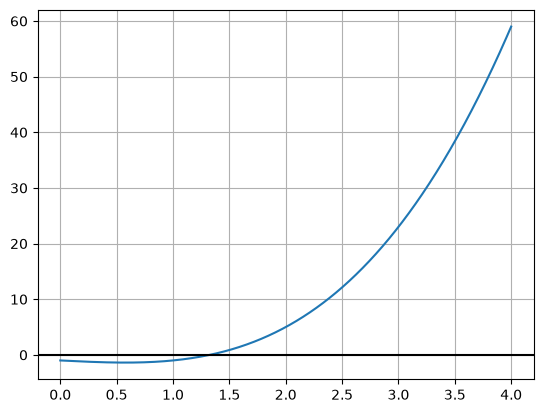

In [17]:
# x^3 - x = 1 -> f(x) = x^3 - x - 1 = 0.
def f(x):
    return x**3 - x - 1

xs = np.linspace(0, 4, 1 << 10)
plt.plot(xs, f(xs))
plt.axhline(0, color='black')
plt.grid(True)
plt.savefig('05_images/4-1.svg')

## What is the slope of the tangent line at $x=2$

In [18]:
def df(x):
    return 3*x**2 - 1

print(df(2))

11


## What is the equation for the tangent line at  $x=2$ Plot it along with the function.

Since $f(2)=5$, the tangent is $y=5+11(x-2)$.

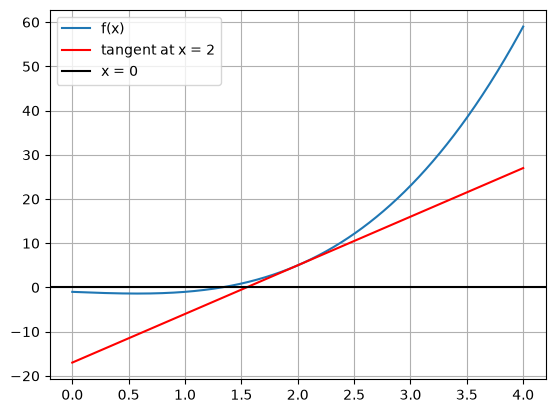

In [19]:
# y = f(2) + f'(2) * (x - 2) = 11x - 17.
plt.plot(xs, f(xs), label='f(x)')
plt.plot(xs, 11*xs - 17, color='red', label='tangent at x = 2')
plt.axhline(0, color='black', label='x = 0')
plt.grid(True)
plt.legend()
plt.savefig('05_images/4-3.svg')

## What is the intercept for that line? That's your new guess.

In [20]:
# y = 0 = 11 * x - 17 -> x = 17 / 11
x1 = 17 / 11
print(x1)

1.5454545454545454


## Now combine everything in to one formula you should get something along the line of



$$
x_{n+1} = \ldots - \frac{\ldots(x_n)}{\ldots(x_n)}
$$

This is called update rule; how you get an improved answer from the previous guess.

After finding those values, use point-slope form for a line: $y - y_0$ = m(x - x_0)$, where $y_0 = f(x_0)$ and $m = f'(x_0)$. We got a general line equation as

$$y - f(x) = f'(x) (x - x_0)$$

then rearrange for y-intersect

$$x = x_0 + \frac{f(x)}{f'(x)}$$

In [21]:
def newton_step(x):
    return x - f(x) / df(x)

## Newton's method converges very very quickly. We will go through the derivation later on.



Now find solution to $x^3−x=1$. Also as a plotting exercise try make something similar to this figure:

Here is how I annotate the figure
`plt.annotate('x%d'%i, xy=(x, 0), xytext=(x,-0.2), fontsize=18)`

<div>
<img src="attachment:trythis.png" width="600"/>
</div>


1.5454545454545454
1.359614915915184
1.325801345005845
1.3247190494171253
1.3247179572458576
1.324717957244746
1.324717957244746
1.324717957244746


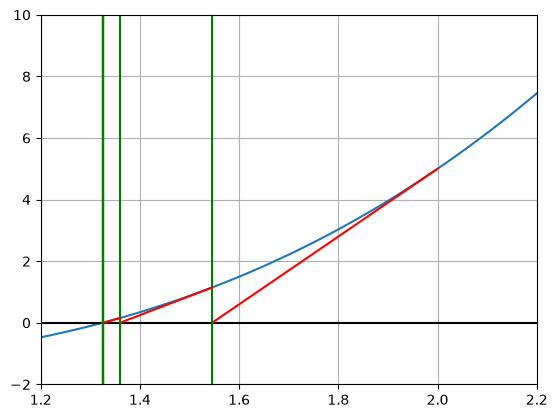

<Figure size 640x480 with 0 Axes>

In [22]:
x = 2.0
plt.plot(xs, f(xs))
plt.axhline(0, color='black')

for i in range(1 << 3):
    x_next = newton_step(x)

    # straight line from (x, f(x)) to (x_next, 0)
    x_coordinates = [x, x_next]
    y_coordinates = [f(x), 0]
    plt.plot(x_coordinates, y_coordinates, color='red')

    plt.axvline(x_next, color='green')

    x = x_next
    print(x)

plt.xlim(1.2, 2.2)
plt.ylim(-2, 10)
plt.grid(True)
plt.show()
plt.savefig('05_images/4-6.svg')

## Solve $\sqrt[3]{x}=0$ by hand. What's $x$?

$x = 0^3 = 0$

## Try Newton's method on it.



Try plotting as you go to see what's going on.

Now you learn that even though it converges super fast. It doesn't guarantee to converge.

For $f(x)=\sqrt[3]{x}$ and $x\ne 0$, we have $f'(x)=\frac{1}{3(\sqrt[3]{x})^2}$. Thus Newton's update is

$$
\begin{aligned}
x_{n+1}
&= x_n-\frac{f(x_n)}{f'(x_n)} \\
&= x_n-\frac{\sqrt[3]{x_n}}{1/[3(\sqrt[3]{x_n})^2]} \\
&= x_n-3(\sqrt[3]{x_n})^3 \\
&= x_n-3x_n \\
&= -2x_n.
\end{aligned}
$$

[1.0, -2.0, 4.0, -8.0, 16.0, -32.0, 64.0, -128.0, 256.0]


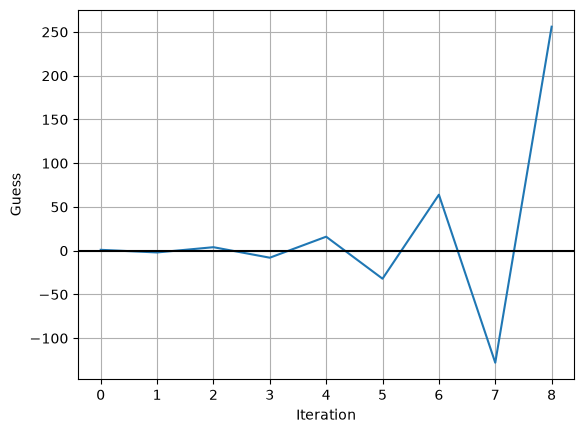

In [23]:
x = 1.0
guesses = [x]
for _ in range(1 << 3):
    x = -2*x
    guesses.append(x)

print(guesses)  # 1, -2, 4, -8, ... (diverge from 0)
plt.plot(range(len(guesses)), guesses)
plt.axhline(0, color='black')
plt.xlabel('Iteration')
plt.ylabel('Guess')
plt.grid(True)
plt.show()

# Bonus


## Simplify (1+x)-1

x

## Then why is this false

In [24]:
x = 1e-10
print (x)
print ((1+x)-1 == x)

1e-10
False


Python's float got limited precision